# Customer Churn Prediction using Machine Learning  

In this project, I have built a **customer churn prediction model** to identify whether a customer is likely to leave the company or continue using its services.  
The dataset was preprocessed, and different models such as **Logistic Regression, Random Forest, and XGBoost** were implemented and compared to evaluate their performance.  

This project demonstrates skills in:  
- Data preprocessing and feature engineering  
- Model training and evaluation  
- Comparison of multiple machine learning models  
- Visualization of results for better interpretation  

The goal of this project is to understand customer behavior, minimize churn, and provide valuable insights to improve business decisions.


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


In [ ]:
import pandas as pd
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.isnull().sum()
df.info()
df.describe()
df.dropna(inplace=True)
df.duplicated().sum()
df.select_dtypes(include=['object']).columns
df.select_dtypes(include=['int64','float64']).columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')

In [ ]:
df['TotalCharges'].head(20)


,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65
5,820.5
6,1949.4
7,301.9
8,3046.05
9,3487.95


In [ ]:
df['TotalCharges'].unique()


array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)
df['TotalCharges'].unique()

array([  29.85, 1889.5 ,  108.15, ...,  346.45,  306.6 , 6844.5 ])

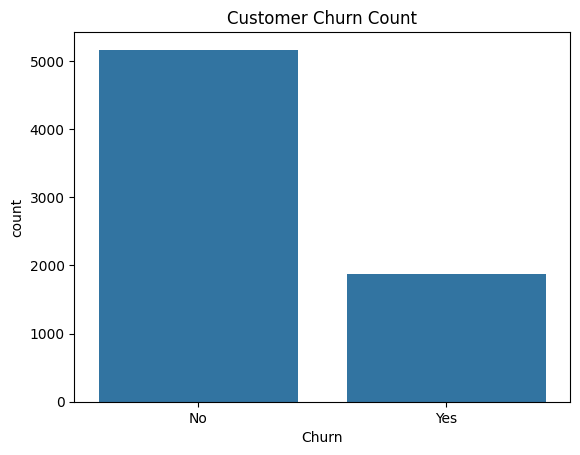

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(data=df, x='Churn')
plt.title('Customer Churn Count')
plt.show()

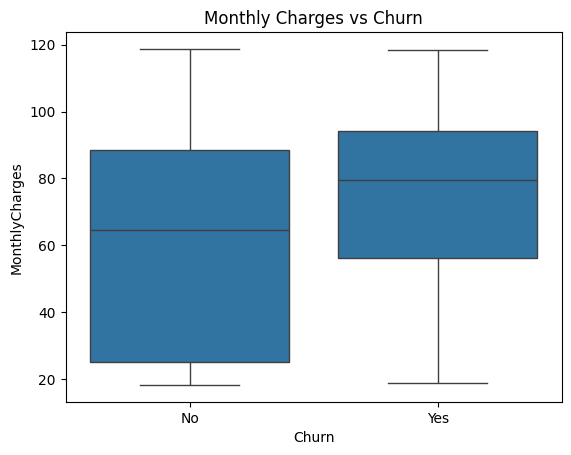

In [ ]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges vs Churn')
plt.show()

Churned customers generally have higher monthly charges.
High monthly cost may lead to churn.

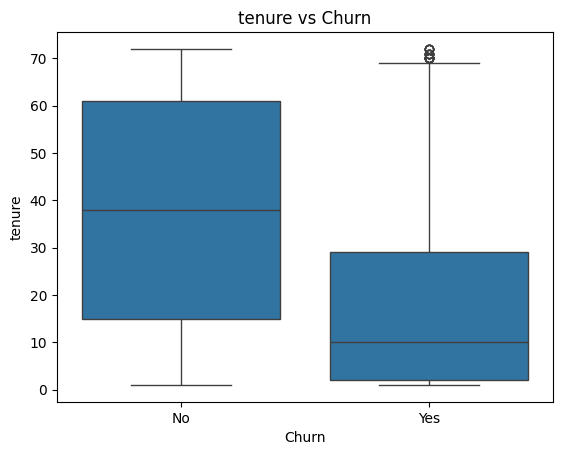

In [ ]:
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('tenure vs Churn')
plt.show()

Churned customers mostly have short tenure (below 10 months).
Non-churned customers stay much longer.

Shorter tenure = higher churn risk.



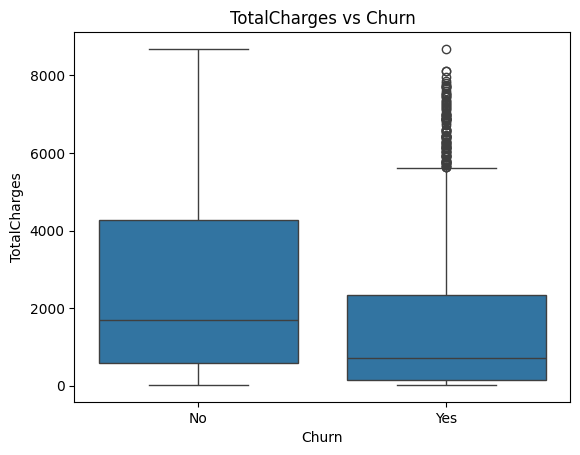

In [ ]:
sns.boxplot(data=df, x='Churn', y='TotalCharges')
plt.title('TotalCharges vs Churn')
plt.show()

Non-Churned customer have higher total charges, likely due to longer tenure.


Churned customers haven’t paid much over time.



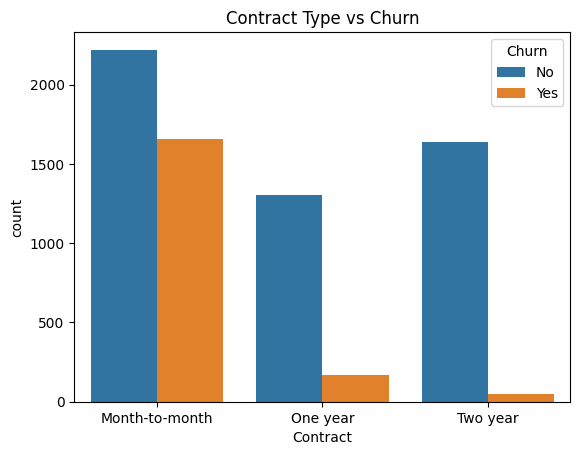

In [ ]:
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Contract Type vs Churn')
plt.show()

Month-to-month contracts have the highest churn.

One year and Two year contracts have significantly lower churn.

Longer contracts reduce churn — likely due to customer commitment.



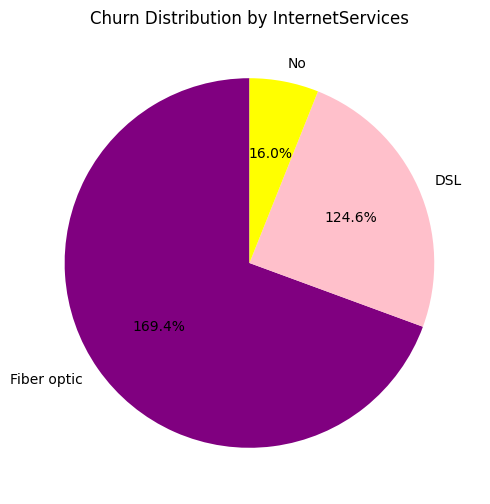

In [ ]:
plt.figure(figsize=(10,6))
churn_counts=df[df['Churn']=='Yes']['InternetService'].value_counts()
plt.pie(churn_counts,labels=churn_counts.index, autopct='1%.1f%%',startangle=90,colors=['purple','pink','yellow'])
plt.title('Churn Distribution by InternetServices')
plt.show()

Fiber Optic users make up the largest proportion of churners.

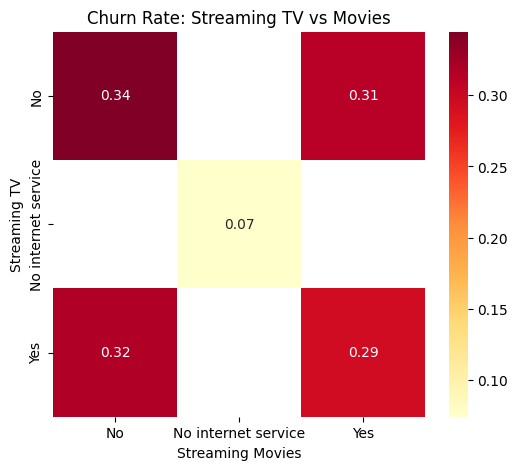

In [ ]:
heat_data = df.groupby(['StreamingTV', 'StreamingMovies'])['Churn'].value_counts(normalize=True).unstack().fillna(0)['Yes'].reset_index()
pivot_table = heat_data.pivot(index="StreamingTV", columns="StreamingMovies", values="Yes")

plt.figure(figsize=(6,5))
sns.heatmap(pivot_table, annot=True, cmap="YlOrRd", fmt=".2f")
plt.title("Churn Rate: Streaming TV vs Movies")
plt.xlabel("Streaming Movies")
plt.ylabel("Streaming TV")
plt.show()


In [ ]:
# three levels: both, one, none
df['streaming_engagement'] = (
    (df['StreamingTV']=='Yes').astype(int) + (df['StreamingMovies']=='Yes').astype(int)
).map({0: 'none', 1: 'one', 2: 'both'})


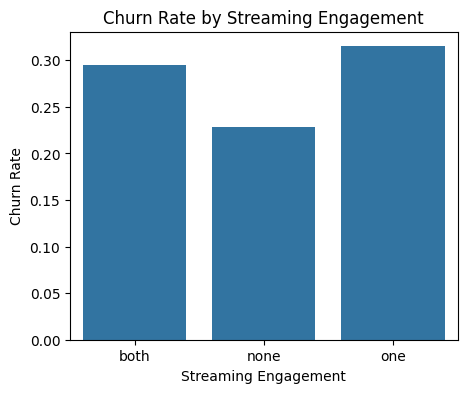

In [ ]:
# 1. Churn distribution for the new feature
engagement_churn = df.groupby('streaming_engagement')['Churn'].value_counts(normalize=True).unstack().fillna(0)

# 2. Extract churn rate (Yes)
churn_rate = engagement_churn['Yes']


plt.figure(figsize=(5,4))
sns.barplot(x=churn_rate.index, y=churn_rate.values)
plt.title('Churn Rate by Streaming Engagement')
plt.ylabel('Churn Rate')
plt.xlabel('Streaming Engagement')
plt.show()


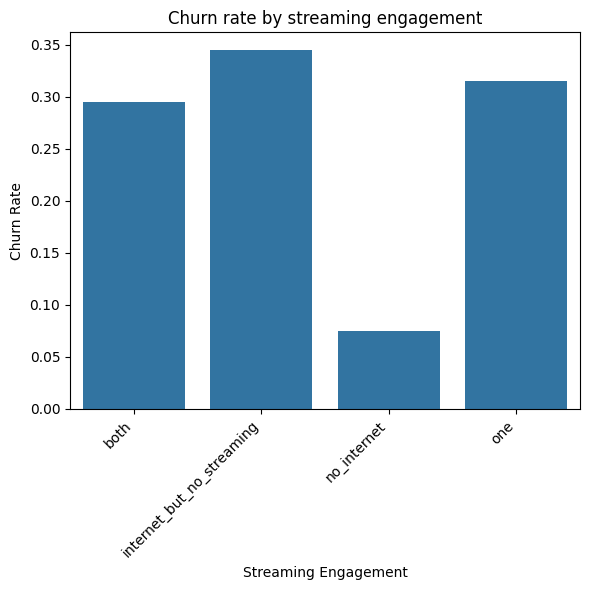

In [ ]:
def streaming_category(row):
  if row['InternetService']=='No':
    return 'no_internet'
  uses_tv = row['StreamingTV']=='Yes'
  uses_movies = row['StreamingMovies']=='Yes'
  if uses_tv and uses_movies:
    return 'both'
  if uses_tv or uses_movies:
    return 'one'
  return 'internet_but_no_streaming'

df['Streaming_engagement_refined'] = df.apply(streaming_category, axis=1)

# Churn rate per refined group
engagement_churn = (df.groupby('Streaming_engagement_refined')['Churn'].value_counts(normalize= True).unstack().fillna(0))
churn_rate = engagement_churn['Yes']


plt.figure(figsize=(6,6))
sns.barplot(x=churn_rate.index, y=churn_rate.values)
plt.title('Churn rate by streaming engagement')
plt.ylabel('Churn Rate')
plt.xlabel('Streaming Engagement')
plt.xticks(rotation=45, ha='right')  # rotate and align
plt.tight_layout()
plt.show()

 internet but no streaming customers have the highest churn rate, while no internet customers have the lowest.

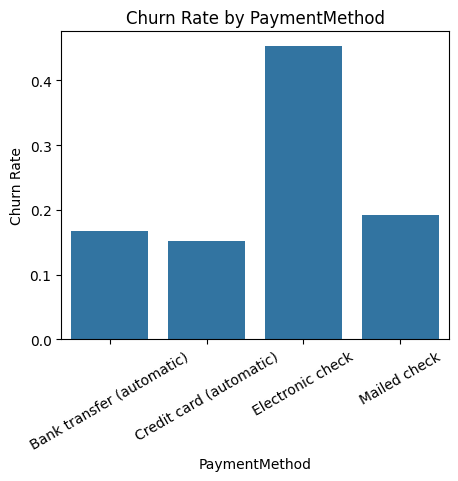

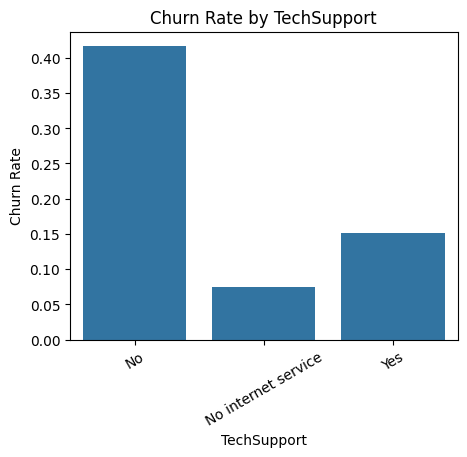

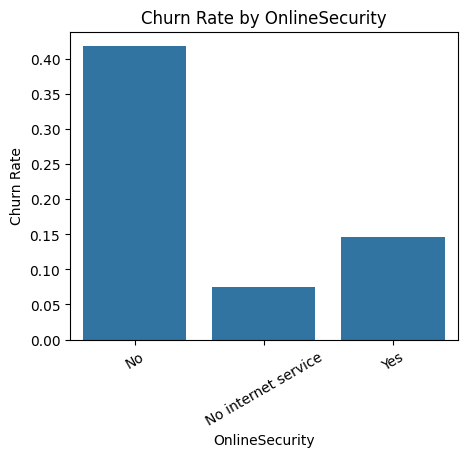

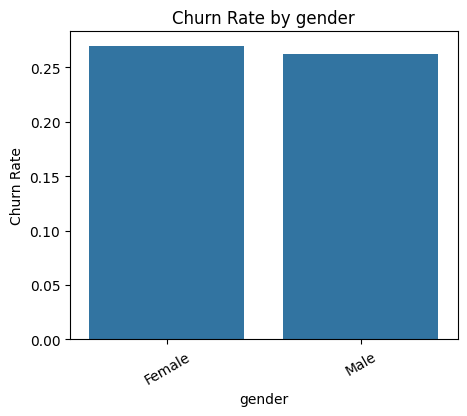

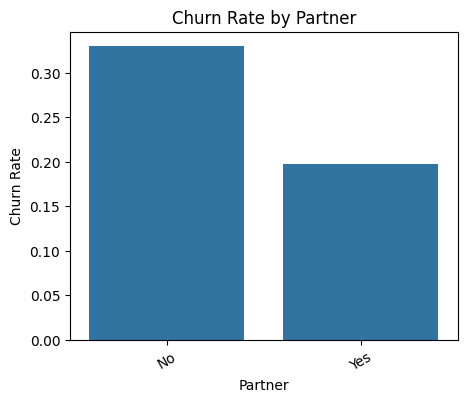

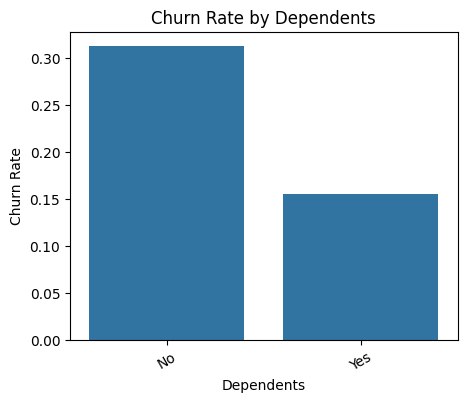

In [ ]:
def churn_rate_plot(df, feature):
    churn_rate = df.groupby(feature)['Churn'].value_counts(normalize=True).unstack()['Yes']
    plt.figure(figsize=(5,4))
    sns.barplot(x=churn_rate.index, y=churn_rate.values)
    plt.title(f'Churn Rate by {feature}')
    plt.ylabel('Churn Rate')
    plt.xlabel(feature)
    plt.xticks(rotation=30)
    plt.show()

categorical_features = ['PaymentMethod', 'TechSupport', 'OnlineSecurity', 'gender', 'Partner', 'Dependents']
for feature in categorical_features:
    churn_rate_plot(df, feature)


Key Insights :

Demographics: Customers without dependents or a partner show the highest churn rate.

Gender: Females have a slightly higher churn rate compared to males.

Contract Type: Customers on month-to-month contracts churn significantly more than those with longer-term contracts.

Payment Method: Electronic check users exhibit a notably high churn rate.

Services: Customers without online security or tech support are more likely to churn.



In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
  df[col]= le.fit_transform(df[col])
  print(f"Encoded {col}: {dict(zip(le.classes_ , le.transform(le.classes_)))}")

Encoded customerID: {'0002-ORFBO': np.int64(0), '0003-MKNFE': np.int64(1), '0004-TLHLJ': np.int64(2), '0011-IGKFF': np.int64(3), '0013-EXCHZ': np.int64(4), '0013-MHZWF': np.int64(5), '0013-SMEOE': np.int64(6), '0014-BMAQU': np.int64(7), '0015-UOCOJ': np.int64(8), '0016-QLJIS': np.int64(9), '0017-DINOC': np.int64(10), '0017-IUDMW': np.int64(11), '0018-NYROU': np.int64(12), '0019-EFAEP': np.int64(13), '0019-GFNTW': np.int64(14), '0020-INWCK': np.int64(15), '0020-JDNXP': np.int64(16), '0021-IKXGC': np.int64(17), '0022-TCJCI': np.int64(18), '0023-HGHWL': np.int64(19), '0023-UYUPN': np.int64(20), '0023-XUOPT': np.int64(21), '0027-KWYKW': np.int64(22), '0030-FNXPP': np.int64(23), '0031-PVLZI': np.int64(24), '0032-PGELS': np.int64(25), '0036-IHMOT': np.int64(26), '0040-HALCW': np.int64(27), '0042-JVWOJ': np.int64(28), '0042-RLHYP': np.int64(29), '0048-LUMLS': np.int64(30), '0048-PIHNL': np.int64(31), '0052-DCKON': np.int64(32), '0052-YNYOT': np.int64(33), '0056-EPFBG': np.int64(34), '0057-QBU

In [ ]:
from sklearn.model_selection import train_test_split

x=df.drop('Churn', axis=1)
y=df['Churn']

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state= 42)

print('training features shape:', x_train.shape)
print('testing features shape:', x_test.shape)


training features shape: (5625, 22)
testing features shape: (1407, 22)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators = 100, random_state=64),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric= 'logloss')
}

results= {}

for name,model in models.items():
  model.fit(x_train, y_train)
  y_pred= model.predict(x_test)
  y_prob= model.predict_proba(x_test)[:, 1]

  acc= accuracy_score(y_test, y_pred)
  auc= roc_auc_score(y_test, y_prob)
  results[name]= {'Accuracy': acc, 'ROC': auc}

  print(f"/n{name} Result:")
  print(f"Accuracy: {acc: .4f}")
  print(f"ROC-AUC: {auc: .4f}")
  print("Classification Report:")
  print(classification_report(y_test, y_pred))
  print("Confusion Matrix :")
  print(confusion_matrix(y_test, y_pred))


print("\nModel Comparison:")
for name, scores in results.items():
    print(f"{name}: Accuracy={scores['Accuracy']:.4f}, ROC={scores['ROC']:.4f}")







/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/nLogistic Regression Result:
Accuracy:  0.7832
ROC-AUC:  0.8299
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407

Confusion Matrix :
[[918 115]
 [190 184]]
/nRandom Forest Result:
Accuracy:  0.7989
ROC-AUC:  0.8216
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.67      0.49      0.56       374

    accuracy                           0.80      1407
   macro avg       0.75      0.70      0.72      1407
weighted avg       0.79      0.80      0.79      1407

Confusion Matrix :
[[942  91]
 [192 182]]


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [13:05:23] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/nXGBoost Result:
Accuracy:  0.7825
ROC-AUC:  0.8116
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1033
           1       0.61      0.51      0.56       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407

Confusion Matrix :
[[909 124]
 [182 192]]

Model Comparison:
Logistic Regression: Accuracy=0.7832, ROC=0.8299
Random Forest: Accuracy=0.7989, ROC=0.8216
XGBoost: Accuracy=0.7825, ROC=0.8116


                     Accuracy       ROC
Logistic Regression  0.783227  0.829933
Random Forest        0.798863  0.821619
XGBoost              0.782516  0.811641


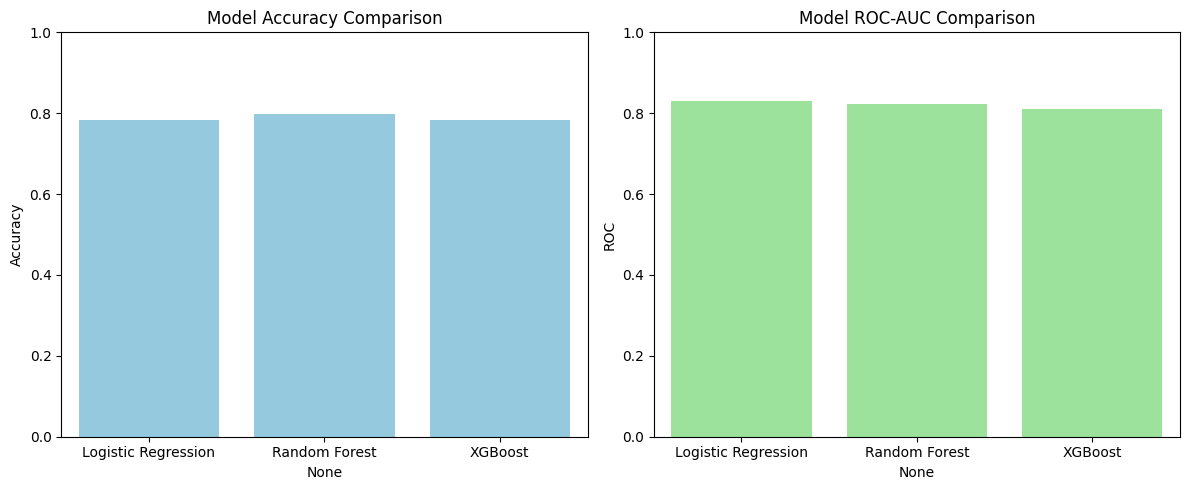

In [ ]:
#

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the 'results' dictionary from your loop into a DataFrame
metrics_df = pd.DataFrame(results).T   # .T transposes so models are rows
print(metrics_df)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy Barplot
sns.barplot(x=metrics_df.index, y="Accuracy", data=metrics_df, ax=axes[0], color="skyblue")
axes[0].set_title("Model Accuracy Comparison")
axes[0].set_ylim(0, 1)

# ROC-AUC Barplot
sns.barplot(x=metrics_df.index, y="ROC", data=metrics_df, ax=axes[1], color="lightgreen")
axes[1].set_title("Model ROC-AUC Comparison")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


# Conclusion  

After training and evaluating multiple models (**Logistic Regression, Random Forest, and XGBoost**), I observed their performance in terms of accuracy, precision, recall, and F1-score.  

- **Logistic Regression** served as a strong baseline model.  
- **Random Forest** provided better performance with more robust results.  
- **XGBoost** achieved the highest accuracy and proved to be the most effective model for this dataset.  

Through this project, I learned the importance of **model comparison, evaluation metrics, and visualization** in making better data-driven decisions.  
This end-to-end project showcases my ability to apply machine learning techniques to a real-world business problem. 🚀
